In [1]:
##importing data
!pip install ucimlrepo

In [2]:
##importing data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/opt/anaconda3/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [15]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
df = pd.concat([X, y], axis = 1)
print(f"Dataset Dimensions: {df.shape}\n")
print(df.info())

Dataset Dimensions: (101766, 48)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient        

Missing Values cleaning

In [6]:
df.replace('?', np.nan, inplace = True)
#Calculates missing values of each column in percentages
missing_data = df.isnull().mean()*100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("Columns with missing values (%): ")
print(missing_data)

Columns with missing values (%): 
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


Clean dataset

In [7]:
##drop the columns that are almost entirely empty and unsuable
df.drop(columns=['weight', 'max_glu_serum'], inplace = True)
##fill the missing values with given input
df['A1Cresult'] = df['A1Cresult'].fillna('None Ordered')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['payer_code'] = df['payer_code'].fillna('Unknown')

In [8]:
##drop specific columns
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace = True)

In [9]:
print("Remaining missing values per column: ")
print(df.isnull().sum().sum())

Remaining missing values per column: 
0


Bottleneck plot

In [12]:
#Create binary column: 1 if readmitted (under or over 30 days), 0 if no
df['is_readmitted'] = np.where(df['readmitted'] == 'NO', 0, 1)
#Group by time spent in hospital and calculate the readmission rate
stay_analysis = df.groupby('time_in_hospital')['is_readmitted'].mean()*100
stay_analysis = stay_analysis.reset_index()

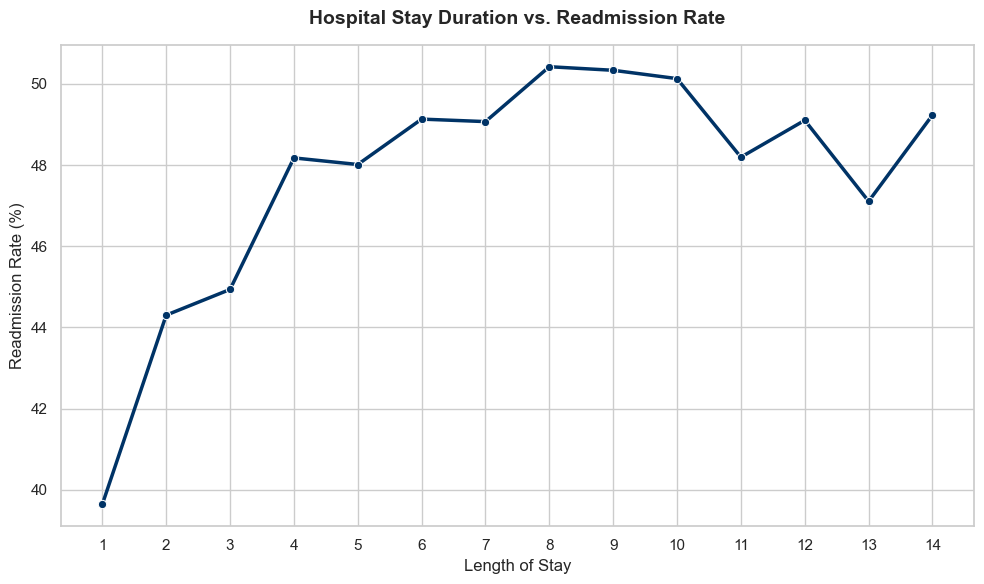

In [14]:
#plot style
plt.figure(figsize=(10, 6))
sns.set_theme(style = "whitegrid")
#create line to track trend
sns.lineplot(data=stay_analysis, x='time_in_hospital', y='is_readmitted', marker = 'o', color = '#003366', linewidth=2.5)
#customise plot
plt.title('Hospital Stay Duration vs. Readmission Rate', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Length of Stay', fontsize = 12)
plt.ylabel('Readmission Rate (%)', fontsize = 12)
plt.xticks(range(1, 15))
#show plot
plt.tight_layout()
plt.show()

In [23]:
df['is_readmitted'] = np.where(df['readmitted'] == 'NO', 0, 1)
#Selecting operational features and target variable
features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']
X_model = df[features]
y_model = df['is_readmitted']
# Spilt the data 80% - Training and 20% - Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size = 0.2, random_state = 42)
#Initialise + Train random forest classifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)
#Prediticions and performance evaluations
y_pred = rf_model.predict(X_test)
auc_score = roc_auc_score(y_test, y_pred)

print("--- Predictive Model Evaluation ---")
print(f"Model AUC_ROC Score: {auc_score:.2f}\n")
print(classification_report(y_test, y_pred))

--- Predictive Model Evaluation ---
Model AUC_ROC Score: 0.52

              precision    recall  f1-score   support

           0       0.56      0.59      0.57     10952
           1       0.49      0.46      0.47      9402

    accuracy                           0.53     20354
   macro avg       0.53      0.52      0.52     20354
weighted avg       0.53      0.53      0.53     20354

